In [2]:
# %% [markdown]
# ### 1. Konfiguration, Imports und Hilfsfunktionen

# %%
from collections import defaultdict
import json
import os
from pathlib import Path
import re
import warnings
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pycocotools.mask as mask_utils
from tidecv import TIDE, datasets
import torch
from ultralytics import YOLO

# Unterdrückt Seaborn/Matplotlib Warnungen von tidecv
warnings.filterwarnings("ignore")

# ======================= KONFIGURATION =======================
GT_LABELS_DIR = Path("./gt_labels_new_tofill")
RECORDINGS_DIR = Path("./recordings_counted")
MASKS_PATH = Path("./outputs_raw_masks_compressed")

TIDE_OUT_DIR = Path("./tide_output_plots")
TIDE_OUT_DIR.mkdir(parents=True, exist_ok=True)
# =============================================================


# 1. Hilfsfunktion: Crop-Box aus _cut.txt laden
def load_crop_box_from_txt(
    finished_folder, video_prefix, frame_nr, task_id, img_shape
):
    h_orig, w_orig = img_shape[:2]
    candidates = [
        finished_folder / f"{video_prefix}_{frame_nr:04d}_cut.txt",
        finished_folder / f"{video_prefix}_{frame_nr}_cut.txt",
        finished_folder / f"{video_prefix}_task-{task_id}_cut.txt",
        finished_folder / f"task-{task_id}_cut.txt",
    ]
    for cand in candidates:
        if cand.exists():
            with open(cand, "r") as f:
                for line in f:
                    line = line.strip()
                    if line and not line.startswith("#"):
                        parts = [int(x.strip()) for x in line.split(",")]
                        if len(parts) == 4:
                            x1, y1, x2, y2 = parts
                            x1 = max(0, min(w_orig, x1))
                            y1 = max(0, min(h_orig, y1))
                            x2 = max(0, min(w_orig, x2))
                            y2 = max(0, min(h_orig, y2))
                            if x2 > x1 and y2 > y1:
                                return x1, y1, x2, y2

    print(
        f"[!] Keine _cut.txt für {video_prefix} Frame {frame_nr:04d} (Task-{task_id}) gefunden -> Nutze volles Bild!"
    )
    return 0, 0, w_orig, h_orig


# 3. Hilfsfunktion: IoU zwischen zwei Masken
def mask_iou(m1, m2):
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return float(inter / union) if union > 0 else 0.0


# 4. Hilfsfunktion: Gesamt-IoU pro Bild
def compute_image_iou(gt_masks_list, pred_masks_list):
    if len(gt_masks_list) == 0 and len(pred_masks_list) == 0:
        return 1.0
    if len(gt_masks_list) == 0 or len(pred_masks_list) == 0:
        return 0.0
    combined_gt = np.clip(np.sum(gt_masks_list, axis=0), 0, 1).astype(np.uint8)
    combined_pred = np.clip(np.sum(pred_masks_list, axis=0), 0, 1).astype(
        np.uint8
    )
    inter = np.logical_and(combined_gt, combined_pred).sum()
    union = np.logical_or(combined_gt, combined_pred).sum()
    return float(inter / union) if union > 0 else 0.0

     🚀 STARTE RAM-SCHONENDE SAM3 TIDE EVALUATION (4GB SAFE)
[+] Gefundene Videos (14 Stück): ['fishvideo30', 'fishvideo31', 'fishvideo32', 'fishvideo33', 'fishvideo34', 'fishvideo38', 'fishvideo39', 'fishvideo40', 'fishvideo80', 'fishvideo81', 'fishvideo83', 'fishvideo84', 'fishvideo85', 'fishvideo86']


--- Verarbeite fishvideo30 (10 Frames) ---

--- Verarbeite fishvideo31 (10 Frames) ---
  📦 Lade SAM-Datei: tracking_results_video_031_0001_to_0040.pkl.gz (für 2 Frames)...
  📦 Lade SAM-Datei: tracking_results_video_031_0035_to_0074.pkl.gz (für 2 Frames)...
  📦 Lade SAM-Datei: tracking_results_video_031_0069_to_0108.pkl.gz (für 1 Frames)...
  📦 Lade SAM-Datei: tracking_results_video_031_0103_to_0142.pkl.gz (für 1 Frames)...
  📦 Lade SAM-Datei: tracking_results_video_031_0137_to_0176.pkl.gz (für 2 Frames)...

--- Verarbeite fishvideo32 (10 Frames) ---
  📦 Lade SAM-Datei: tracking_results_video_032_0001_to_0040.pkl.gz (für 2 Frames)...
  📦 Lade SAM-Datei: tracking_results_video_032_0035_t

[ WARN:0@232.580] global loadsave.cpp:1063 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


[+] TIDE-Plots gespeichert in: /mnt/c/Users/sinke/Desktop/Masterarbeit/sam3/tide_output_plots

     🔍 DETAILLIERTE ZERLEGUNG DES SAM3-BACKGROUND-FEHLERS
Gesamte SAM3-Vorhersagen:          693
  └── Richtig getrackte Fische (TP): 526 (75.9 %)
  └── Background-Fehler (FP gesamt): 167 (24.1 %)

---------------------------------------------------------------------------
Stör-Kategorie                      | Anzahl FP  | Anteil am Background-Fehler
---------------------------------------------------------------------------
Snail (Schnecke)                    |       37   |                   22.2 %
FishNeighbour (Nachbar)             |       11   |                    6.6 %
Reflection (Reflexion)              |       32   |                   19.2 %
Pure Background (Kies/Wasser/Glas)  |       87   |                   52.1 %
---------------------------------------------------------------------------
TOTAL BACKGROUND-FEHLER             |      167   |                 100.0 %


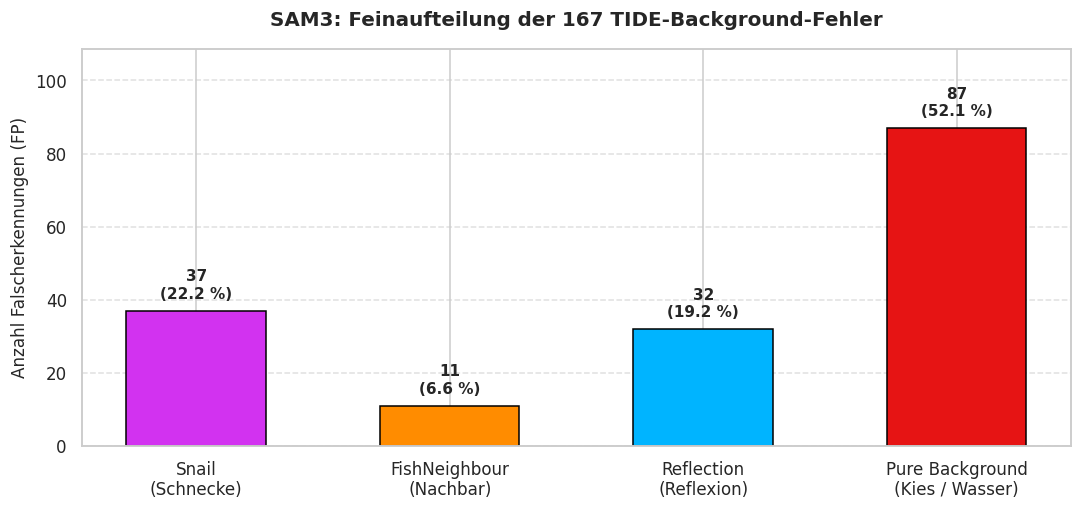

In [3]:
# %% [markdown]
# ### 2. SAM3-Masken RAM-schonend laden, TIDE evaluieren & Fehler aufschlüsseln

# %%
from collections import defaultdict
import gc
import gzip
import json
import os
from pathlib import Path
import pickle
import re
import warnings
import zipfile
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pycocotools.mask as mask_utils
from tidecv import TIDE, datasets

warnings.filterwarnings("ignore")

print("=" * 75)
print("     🚀 STARTE RAM-SCHONENDE SAM3 TIDE EVALUATION (4GB SAFE)")
print("=" * 75)


# ---------------------------------------------------------
# 1. HILFSFUNKTIONEN
# ---------------------------------------------------------
def load_raw_pickle(file_path):
    """Lädt eine einzelne komprimierte Pickle-Datei."""
    if file_path.suffix == ".zip" or zipfile.is_zipfile(file_path):
        with zipfile.ZipFile(file_path, "r") as zf:
            pkl_name = [n for n in zf.namelist() if n.endswith(".pkl")][0]
            with zf.open(pkl_name) as f:
                return pickle.load(f)
    elif file_path.suffix == ".gz" or str(file_path).endswith(".pkl.gz"):
        with gzip.open(file_path, "rb") as f:
            return pickle.load(f)
    else:
        with open(file_path, "rb") as f:
            return pickle.load(f)


def load_crop_box_from_txt(
    finished_folder, video_prefix, frame_nr, task_id, img_shape
):
    h_orig, w_orig = img_shape[:2]
    candidates = [
        finished_folder / f"{video_prefix}_{frame_nr:04d}_cut.txt",
        finished_folder / f"{video_prefix}_{frame_nr}_cut.txt",
        finished_folder / f"{video_prefix}_task-{task_id}_cut.txt",
        finished_folder / f"task-{task_id}_cut.txt",
    ]
    for cand in candidates:
        if cand.exists():
            with open(cand, "r") as f:
                for line in f:
                    line = line.strip()
                    if line and not line.startswith("#"):
                        parts = [int(x.strip()) for x in line.split(",")]
                        if len(parts) == 4:
                            x1, y1, x2, y2 = parts
                            x1 = max(0, min(w_orig, x1))
                            y1 = max(0, min(h_orig, y1))
                            x2 = max(0, min(w_orig, x2))
                            y2 = max(0, min(h_orig, y2))
                            if x2 > x1 and y2 > y1:
                                return x1, y1, x2, y2
    return 0, 0, w_orig, h_orig


def mask_iou(m1, m2):
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return float(inter / union) if union > 0 else 0.0


def compute_image_iou(gt_masks_list, pred_masks_list):
    if len(gt_masks_list) == 0 and len(pred_masks_list) == 0:
        return 1.0
    if len(gt_masks_list) == 0 or len(pred_masks_list) == 0:
        return 0.0
    combined_gt = np.clip(np.sum(gt_masks_list, axis=0), 0, 1).astype(np.uint8)
    combined_pred = np.clip(np.sum(pred_masks_list, axis=0), 0, 1).astype(
        np.uint8
    )
    inter = np.logical_and(combined_gt, combined_pred).sum()
    union = np.logical_or(combined_gt, combined_pred).sum()
    return float(inter / union) if union > 0 else 0.0


# ---------------------------------------------------------
# 2. VIDEOS ERMITTELN
# ---------------------------------------------------------
evaluated_samples = []

txt_files = sorted(list(GT_LABELS_DIR.glob("fishvideo*.txt")))
if not txt_files:
    txt_files = sorted(
        [
            f
            for f in GT_LABELS_DIR.glob("*_finished/*.txt")
            if not f.name.endswith("_cut.txt")
        ]
    )

if txt_files:
    video_prefixes = sorted(
        list(set([tf.stem.replace("_finished", "") for tf in txt_files]))
    )
else:
    video_prefixes = sorted(
        [
            d.name.replace("_finished", "")
            for d in GT_LABELS_DIR.glob("*_finished")
        ]
    )

print(
    f"[+] Gefundene Videos ({len(video_prefixes)} Stück): {video_prefixes}\n"
)

all_sam_files = list(MASKS_PATH.glob("*")) + list(MASKS_PATH.glob("*/*"))

# ---------------------------------------------------------
# 3. HAUPTSCHLEIFE ÜBER ALLE VIDEOS
# ---------------------------------------------------------
for video_prefix in video_prefixes:
    num_match = re.search(r"\d+", video_prefix)
    if not num_match:
        continue
    v_num = int(num_match.group(0))

    finished_candidates = [
        GT_LABELS_DIR / f"{video_prefix}_finished",
        GT_LABELS_DIR / video_prefix,
        GT_LABELS_DIR / f"fishvideo_{v_num}_finished",
    ]
    finished_folder = next((p for p in finished_candidates if p.exists()), None)

    txt_candidates = [
        GT_LABELS_DIR / f"{video_prefix}.txt",
        RECORDINGS_DIR / f"{video_prefix}.txt",
    ]
    if finished_folder and finished_folder.exists():
        for tf in finished_folder.glob("*.txt"):
            if not tf.name.endswith("_cut.txt"):
                txt_candidates.insert(0, tf)

    txt_file = next((p for p in txt_candidates if p.exists()), None)

    if not finished_folder or not txt_file:
        print(f"[!] Überspringe {video_prefix}: Finished-Ordner oder TXT fehlt.")
        continue

    # Frames-Liste und GT-Masken einlesen
    with open(txt_file, "r") as f:
        content = f.read()
    frame_numbers = [int(num) for num in re.findall(r"\d+", content)]

    all_mask_files = sorted(
        list(finished_folder.glob("*.npy"))
        + list(finished_folder.glob("*.npz"))
    )
    task_groups = defaultdict(lambda: defaultdict(list))
    for mf in all_mask_files:
        match = re.search(r"task-(\d+)", mf.name)
        if match:
            task_id = int(match.group(1))
            name_lower = mf.name.lower()
            if (
                "tag-fisch" in name_lower
                or "tag-fish-" in name_lower
                or "tag-fish." in name_lower
                or name_lower.endswith("-fish.npy")
            ):
                task_groups[task_id]["fish"].append(mf)
            elif "tag-snail" in name_lower:
                task_groups[task_id]["snail"].append(mf)
            elif "tag-fishneighbour" in name_lower:
                task_groups[task_id]["neighbour"].append(mf)
            elif "tag-reflection" in name_lower:
                task_groups[task_id]["reflection"].append(mf)

    sorted_task_ids = sorted(task_groups.keys())
    min_len = min(len(frame_numbers), len(sorted_task_ids))

    print(f"\n--- Verarbeite {video_prefix} ({min_len} Frames) ---")

    # -------------------------------------------------------------------------
    # SCHRITT A: Zuordnung Frame -> SAM-Pickle-Datei vorbereiten
    # -------------------------------------------------------------------------
    pattern = re.compile(
        rf".*video_?0*{v_num}_(\d+)_to_(\d+).*", re.IGNORECASE
    )
    sam_video_files = []
    for f in all_sam_files:
        m = pattern.search(f.name)
        if m:
            start_f = int(m.group(1))
            end_f = int(m.group(2))
            sam_video_files.append((f, start_f, end_f))

    # Gruppiere Frames nach der jeweiligen SAM-Pickle-Datei
    file_to_frames = defaultdict(list)
    unassigned_frames = []

    for frame_nr, task_id in zip(
        frame_numbers[:min_len], sorted_task_ids[:min_len]
    ):
        assigned = False
        for s_file, s_start, s_end in sam_video_files:
            if s_start <= frame_nr <= s_end:
                file_to_frames[s_file].append((frame_nr, task_id, s_start))
                assigned = True
                break  # Ersten Treffer nehmen
        if not assigned:
            unassigned_frames.append((frame_nr, task_id))

    # Dictionary für die extrahierten, leichten SAM-Masken pro Frame
    extracted_sam_masks_by_frame = defaultdict(list)

    # -------------------------------------------------------------------------
    # SCHRITT B: Jede 4-GB-Pickle-Datei GENAU EINMAL laden & sofort RAM freigeben
    # -------------------------------------------------------------------------
    for s_file, frame_info_list in file_to_frames.items():
        print(
            f"  📦 Lade SAM-Datei: {s_file.name} (für {len(frame_info_list)} Frames)..."
        )
        try:
            sam_data = load_raw_pickle(s_file)

            for frame_nr, task_id, s_start in frame_info_list:
                rel_idx = frame_nr - s_start

                # Frame-Eintrag holen
                frame_entry = None
                if rel_idx in sam_data:
                    frame_entry = sam_data[rel_idx]
                elif str(rel_idx) in sam_data:
                    frame_entry = sam_data[str(rel_idx)]
                elif frame_nr in sam_data:
                    frame_entry = sam_data[frame_nr]
                elif str(frame_nr) in sam_data:
                    frame_entry = sam_data[str(frame_nr)]

                if frame_entry and isinstance(frame_entry, dict):
                    raw_masks = frame_entry.get("out_binary_masks", None)
                    if raw_masks is not None:
                        if hasattr(raw_masks, "cpu") and hasattr(
                            raw_masks, "numpy"
                        ):
                            raw_masks = raw_masks.cpu().numpy()
                        raw_masks = np.array(raw_masks)

                        # Masken für diesen Frame sichern
                        frame_masks = []
                        for idx in range(len(raw_masks)):
                            m = raw_masks[idx]
                            if m.ndim == 3:
                                m = m.squeeze()
                            if m.ndim == 2 and m.sum() > 0:
                                frame_masks.append((m > 0).astype(np.uint8))

                        extracted_sam_masks_by_frame[frame_nr] = frame_masks

            # 4 GB RAM SOFORT FREIGEBEN!
            del sam_data
            gc.collect()

        except Exception as e:
            print(f"  [!] Fehler beim Entpacken von {s_file.name}: {e}")

    # -------------------------------------------------------------------------
    # SCHRITT C: GT zuschneiden, IoU berechnen & Samples speichern
    # -------------------------------------------------------------------------
    for frame_nr, task_id in zip(
        frame_numbers[:min_len], sorted_task_ids[:min_len]
    ):
        # Bilddimensionen aus GT bestimmen
        first_mask_file = (
            task_groups[task_id]["fish"][0]
            if task_groups[task_id]["fish"]
            else all_mask_files[0]
        )
        data = np.load(first_mask_file)
        m_sample = (
            data[list(data.keys())[0]]
            if first_mask_file.suffix == ".npz"
            else data
        )
        h_orig, w_orig = m_sample.shape[:2]

        x1, y1, x2, y2 = load_crop_box_from_txt(
            finished_folder, video_prefix, frame_nr, task_id, (h_orig, w_orig)
        )
        h_crop = y2 - y1
        w_crop = x2 - x1

        def load_cropped_gt(file_list):
            masks = []
            for mf in file_list:
                d = np.load(mf)
                m = (
                    d[list(d.keys())[0]] if mf.suffix == ".npz" else d
                ).astype(np.uint8)
                if m.ndim == 3:
                    m = m.squeeze()
                if m.shape[:2] != (h_orig, w_orig):
                    m = cv2.resize(
                        m, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST
                    )
                m_c = (m[y1:y2, x1:x2] > 0).astype(np.uint8)
                if m_c.sum() > 0:
                    masks.append(m_c)
            return masks

        gt_fish_masks = load_cropped_gt(task_groups[task_id]["fish"])
        distractor_masks = {
            "snail": load_cropped_gt(task_groups[task_id]["snail"]),
            "neighbour": load_cropped_gt(task_groups[task_id]["neighbour"]),
            "reflection": load_cropped_gt(task_groups[task_id]["reflection"]),
        }

        # Extrahierte SAM-Masken auf Crop zuschneiden
        raw_sam = extracted_sam_masks_by_frame.get(frame_nr, [])
        sam_pred_masks = []
        for m in raw_sam:
            if m.shape[:2] != (h_orig, w_orig):
                m = cv2.resize(
                    m, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST
                )
            m_c = (m[y1:y2, x1:x2] > 0).astype(np.uint8)
            if m_c.sum() > 0:
                sam_pred_masks.append(m_c)

        iou = compute_image_iou(gt_fish_masks, sam_pred_masks)

        evaluated_samples.append(
            {
                "video": video_prefix,
                "task_id": task_id,
                "frame": frame_nr,
                "gt_fish_masks": gt_fish_masks,
                "distractor_masks": distractor_masks,
                "pred_masks": sam_pred_masks,
                "num_gt": len(gt_fish_masks),
                "num_pred": len(sam_pred_masks),
                "iou": iou,
                "crop_coords": (x1, y1, x2, y2),
                "h_crop": h_crop,
                "w_crop": w_crop,
            }
        )

print(
    f"\n[+] Insgesamt {len(evaluated_samples)} Frames erfolgreich und ohne RAM-Überlauf evaluiert.\n"
)

# ---------------------------------------------------------
# 4. TIDE EVALUATION FÜR SAM3
# ---------------------------------------------------------
if len(evaluated_samples) > 0:
    gt_coco = {
        "images": [],
        "annotations": [],
        "categories": [{"id": 1, "name": "fish", "supercategory": "animal"}],
    }
    pred_coco = []
    ann_id_counter = 1

    for img_id, sample in enumerate(evaluated_samples, 1):
        h_crop, w_crop = sample["h_crop"], sample["w_crop"]
        gt_coco["images"].append(
            {
                "id": img_id,
                "file_name": f"{sample['video']}_{sample['frame']:04d}.jpg",
                "width": w_crop,
                "height": h_crop,
            }
        )

        for inst_mask in sample["gt_fish_masks"]:
            if inst_mask.sum() == 0:
                continue
            rle = mask_utils.encode(np.asfortranarray(inst_mask))
            rle["counts"] = rle["counts"].decode("utf-8")
            bbox = mask_utils.toBbox(rle).tolist()
            area = float(mask_utils.area(rle))

            contours, _ = cv2.findContours(
                inst_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )
            polygons = [
                c.reshape(-1, 2).ravel().tolist()
                for c in contours
                if len(c) >= 3
            ]

            gt_coco["annotations"].append(
                {
                    "id": ann_id_counter,
                    "image_id": img_id,
                    "category_id": 1,
                    "segmentation": polygons if len(polygons) > 0 else rle,
                    "area": area,
                    "bbox": bbox,
                    "iscrowd": 0,
                }
            )
            ann_id_counter += 1

        for bin_pred in sample["pred_masks"]:
            if bin_pred.sum() == 0:
                continue
            rle_pred = mask_utils.encode(np.asfortranarray(bin_pred))
            rle_pred["counts"] = rle_pred["counts"].decode("utf-8")
            bbox_pred = mask_utils.toBbox(rle_pred).tolist()

            pred_coco.append(
                {
                    "image_id": img_id,
                    "category_id": 1,
                    "bbox": bbox_pred,
                    "score": 1.0,  # Binäre SAM-Tracks
                    "segmentation": rle_pred,
                }
            )

    gt_json = TIDE_OUT_DIR / "tide_gt_sam_temp.json"
    pred_json = TIDE_OUT_DIR / "tide_pred_sam_temp.json"

    with open(gt_json, "w") as f:
        json.dump(gt_coco, f)
    with open(pred_json, "w") as f:
        json.dump(pred_coco, f)

    tide = TIDE()
    gt_dataset = datasets.COCO(str(gt_json))
    pred_dataset = datasets.COCOResult(str(pred_json))

    print("--- 1. SAM3 Mask-Evaluation (Segmentierung) ---")
    tide.evaluate(
        gt_dataset, pred_dataset, mode=TIDE.MASK, name="SAM3 Mask-Seg"
    )

    print("\n--- 2. SAM3 Box-Evaluation (Bounding Box) ---")
    tide.evaluate(gt_dataset, pred_dataset, mode=TIDE.BOX, name="SAM3 Box-Det")

    print("\n" + "=" * 75)
    print("              📊 OFFIZIELLE TIDE ERGEBNIS-TABELLE (SAM3)")
    print("=" * 75)
    tide.summarize()
    tide.plot(out_dir=str(TIDE_OUT_DIR))
    print(f"[+] TIDE-Plots gespeichert in: {TIDE_OUT_DIR.resolve()}\n")

    # ---------------------------------------------------------
    # 5. FEINAUFTEILUNG DES SAM3-BACKGROUND-FEHLERS
    # ---------------------------------------------------------
    print("=" * 75)
    print("     🔍 DETAILLIERTE ZERLEGUNG DES SAM3-BACKGROUND-FEHLERS")
    print("=" * 75)

    bg_breakdown = {
        "Snail (Schnecke)": 0,
        "FishNeighbour (Nachbar)": 0,
        "Reflection (Reflexion)": 0,
        "Pure Background (Kies/Wasser/Glas)": 0,
    }
    true_fish_matches = 0
    total_predictions = 0

    for sample in evaluated_samples:
        gt_fishes = sample["gt_fish_masks"]
        distractors = sample["distractor_masks"]
        for pred_m in sample["pred_masks"]:
            total_predictions += 1
            if any(mask_iou(pred_m, gt_f) >= 0.5 for gt_f in gt_fishes):
                true_fish_matches += 1
                continue

            best_cat = "Pure Background (Kies/Wasser/Glas)"
            max_iou = 0.10
            for dist_m in distractors.get("snail", []):
                if mask_iou(pred_m, dist_m) > max_iou:
                    max_iou = mask_iou(pred_m, dist_m)
                    best_cat = "Snail (Schnecke)"
            for dist_m in distractors.get("neighbour", []):
                if mask_iou(pred_m, dist_m) > max_iou:
                    max_iou = mask_iou(pred_m, dist_m)
                    best_cat = "FishNeighbour (Nachbar)"
            for dist_m in distractors.get("reflection", []):
                if mask_iou(pred_m, dist_m) > max_iou:
                    max_iou = mask_iou(pred_m, dist_m)
                    best_cat = "Reflection (Reflexion)"
            bg_breakdown[best_cat] += 1

    total_fp = total_predictions - true_fish_matches
    print(f"Gesamte SAM3-Vorhersagen:          {total_predictions}")
    print(
        f"  └── Richtig getrackte Fische (TP): {true_fish_matches} ({true_fish_matches/max(1, total_predictions)*100:.1f} %)"
    )
    print(
        f"  └── Background-Fehler (FP gesamt): {total_fp} ({total_fp/max(1, total_predictions)*100:.1f} %)\n"
    )
    print("-" * 75)
    print(
        f"{'Stör-Kategorie':<35} | {'Anzahl FP':<10} | {'Anteil am Background-Fehler':<25}"
    )
    print("-" * 75)
    for cat_name, cnt in bg_breakdown.items():
        pct = (cnt / max(1, total_fp)) * 100
        print(f"{cat_name:<35} | {cnt:>8}   | {pct:>22.1f} %")
    print("-" * 75)
    print(f"{'TOTAL BACKGROUND-FEHLER':<35} | {total_fp:>8}   | {'100.0 %':>23}")
    print("=" * 75)

    # Plot der Background-Zerlegung
    categories = [
        "Snail\n(Schnecke)",
        "FishNeighbour\n(Nachbar)",
        "Reflection\n(Reflexion)",
        "Pure Background\n(Kies / Wasser)",
    ]
    counts = [
        bg_breakdown["Snail (Schnecke)"],
        bg_breakdown["FishNeighbour (Nachbar)"],
        bg_breakdown["Reflection (Reflexion)"],
        bg_breakdown["Pure Background (Kies/Wasser/Glas)"],
    ]
    colors = ["#d232f0", "#ff8c00", "#00b4ff", "#e61414"]

    plt.figure(figsize=(10, 4.8), dpi=110)
    bars = plt.bar(
        categories, counts, color=colors, edgecolor="black", width=0.55
    )
    plt.title(
        f"SAM3: Feinaufteilung der {total_fp} TIDE-Background-Fehler",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )
    plt.ylabel("Anzahl Falscherkennungen (FP)", fontsize=11)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    for bar in bars:
        h = bar.get_height()
        pct = (h / max(1, total_fp)) * 100
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h + max(0.5, total_fp * 0.015),
            f"{h}\n({pct:.1f} %)",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=10,
        )
    plt.ylim(0, max(counts) * 1.25 if max(counts) > 0 else 10)
    plt.tight_layout()
    plt.show()


       🏆 TOP 5 BESTE ERGEBNISSE (Höchste IoU)


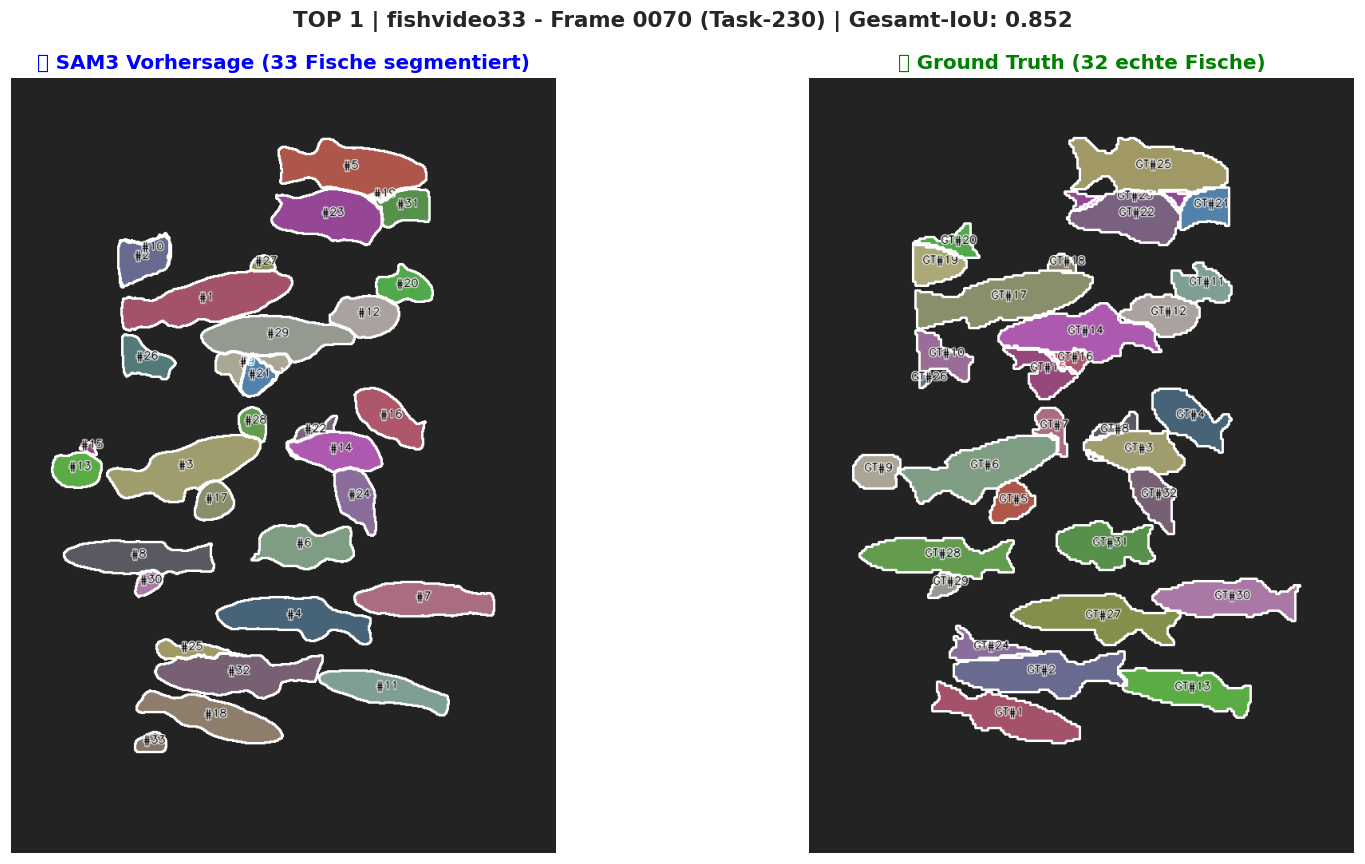

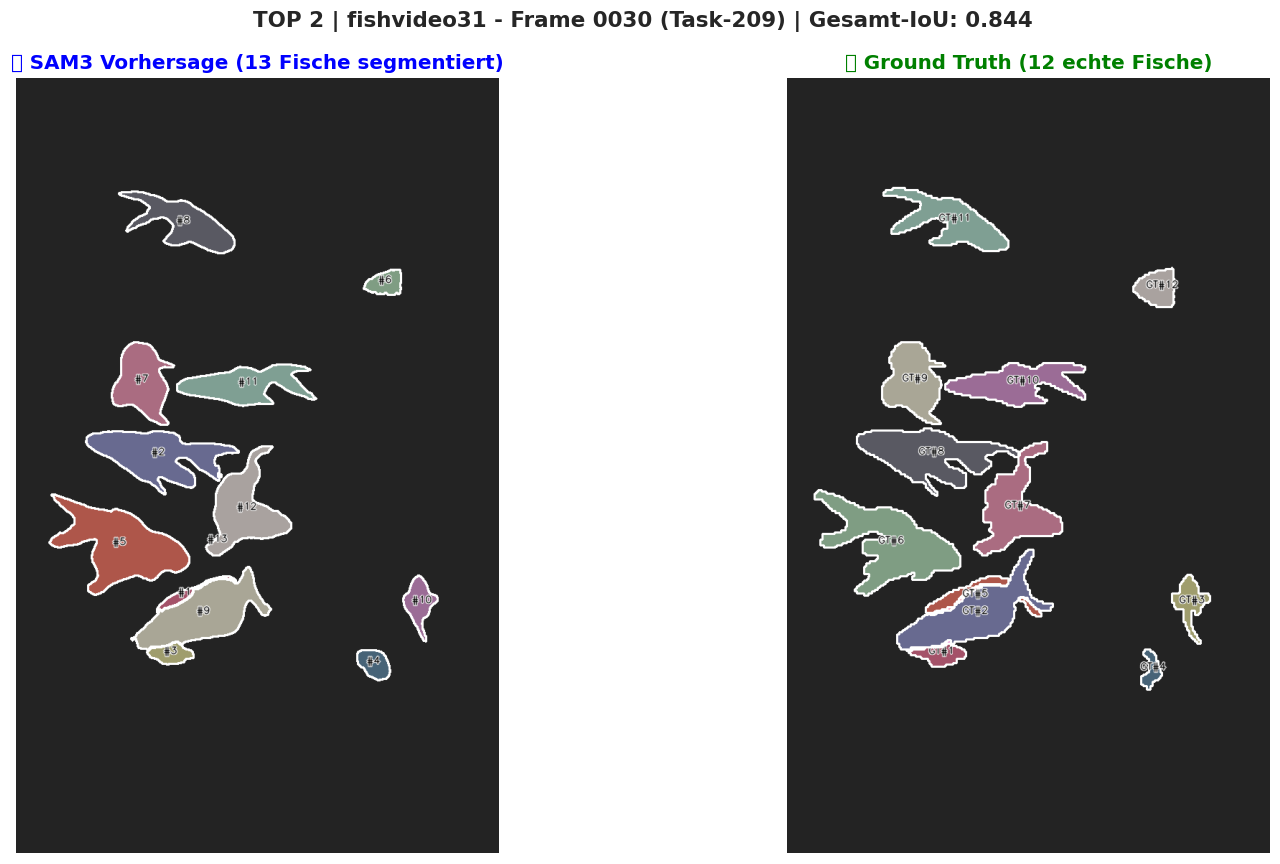

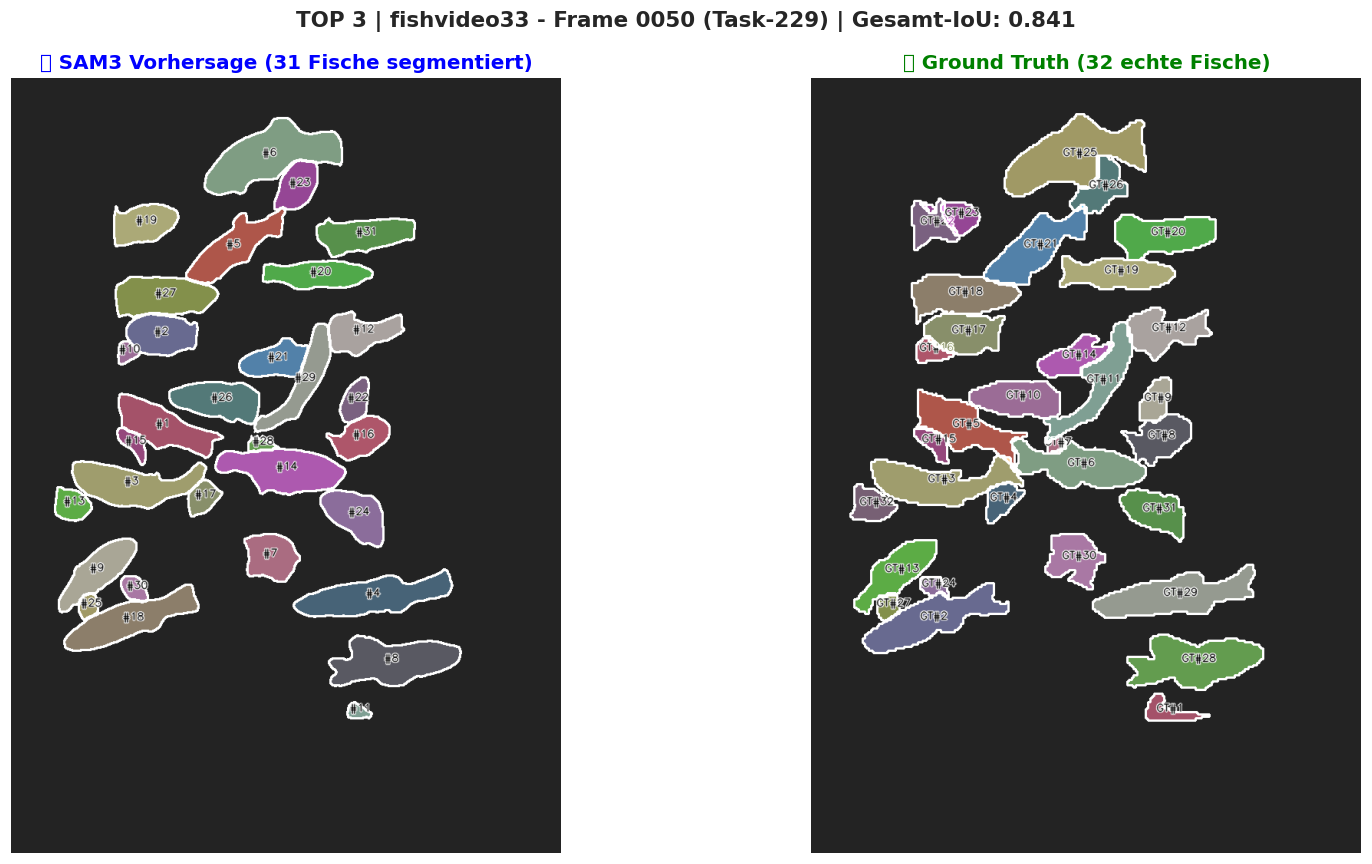

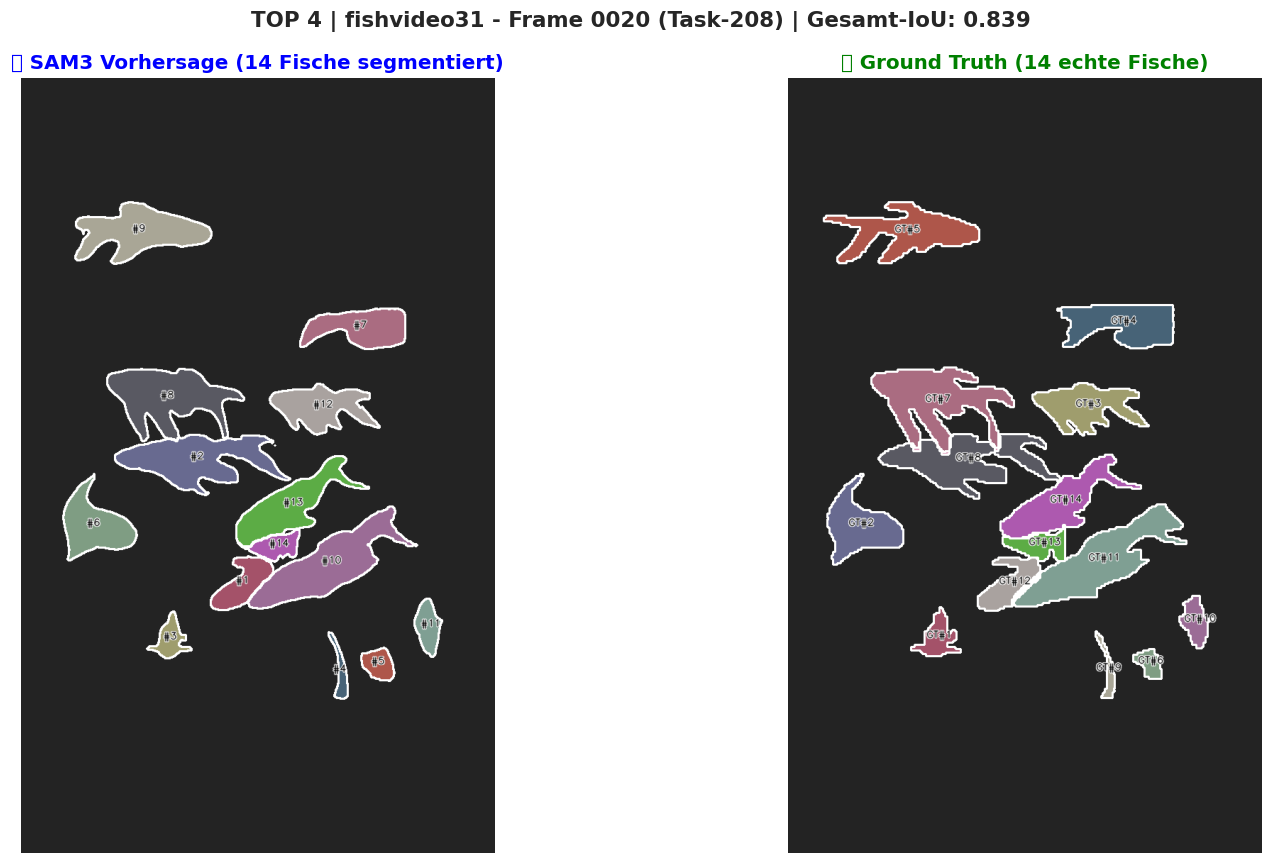

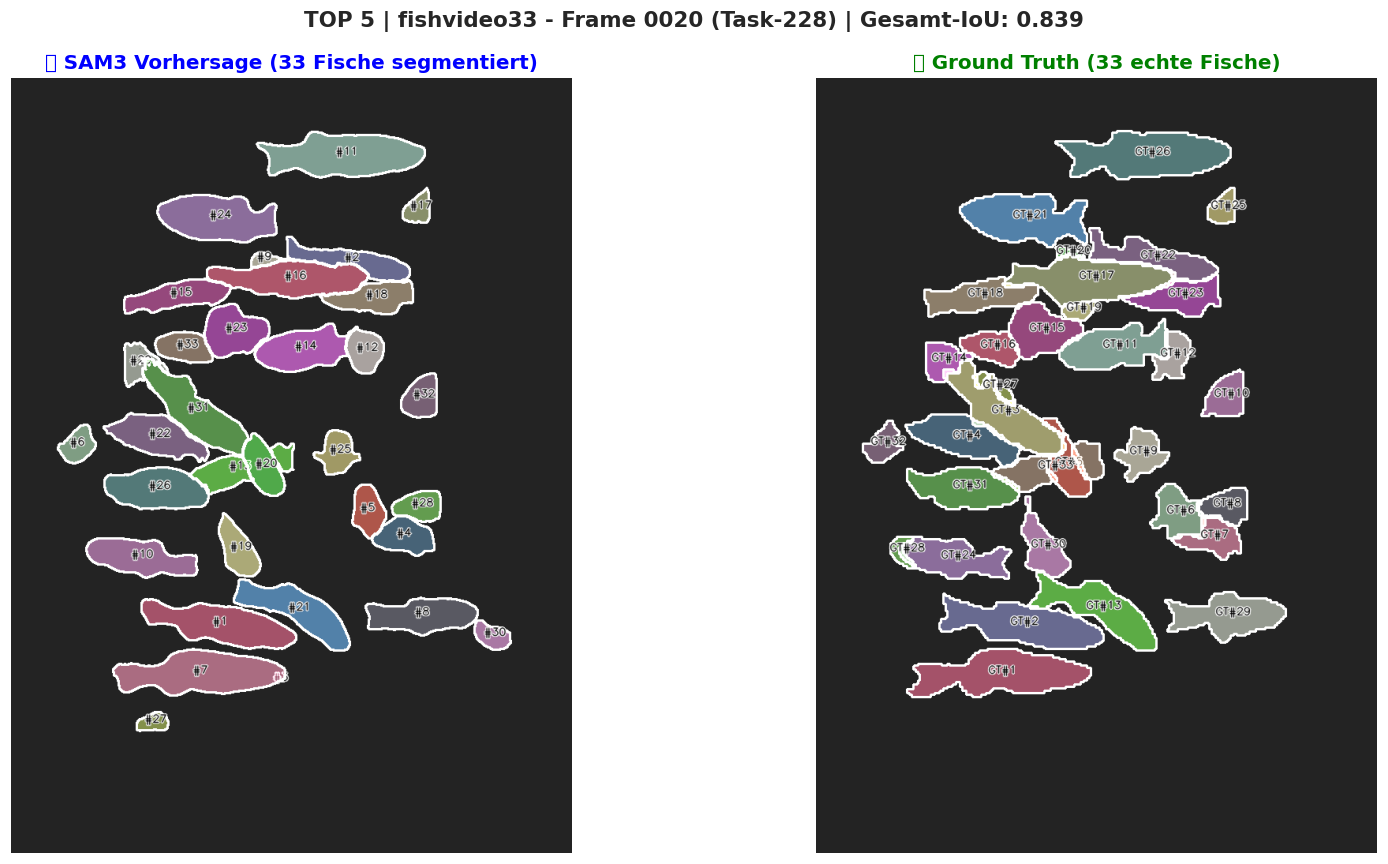


       ⚠️ FLOP 5 SCHLECHTESTE ERGEBNISSE (Niedrigste IoU / Misses)


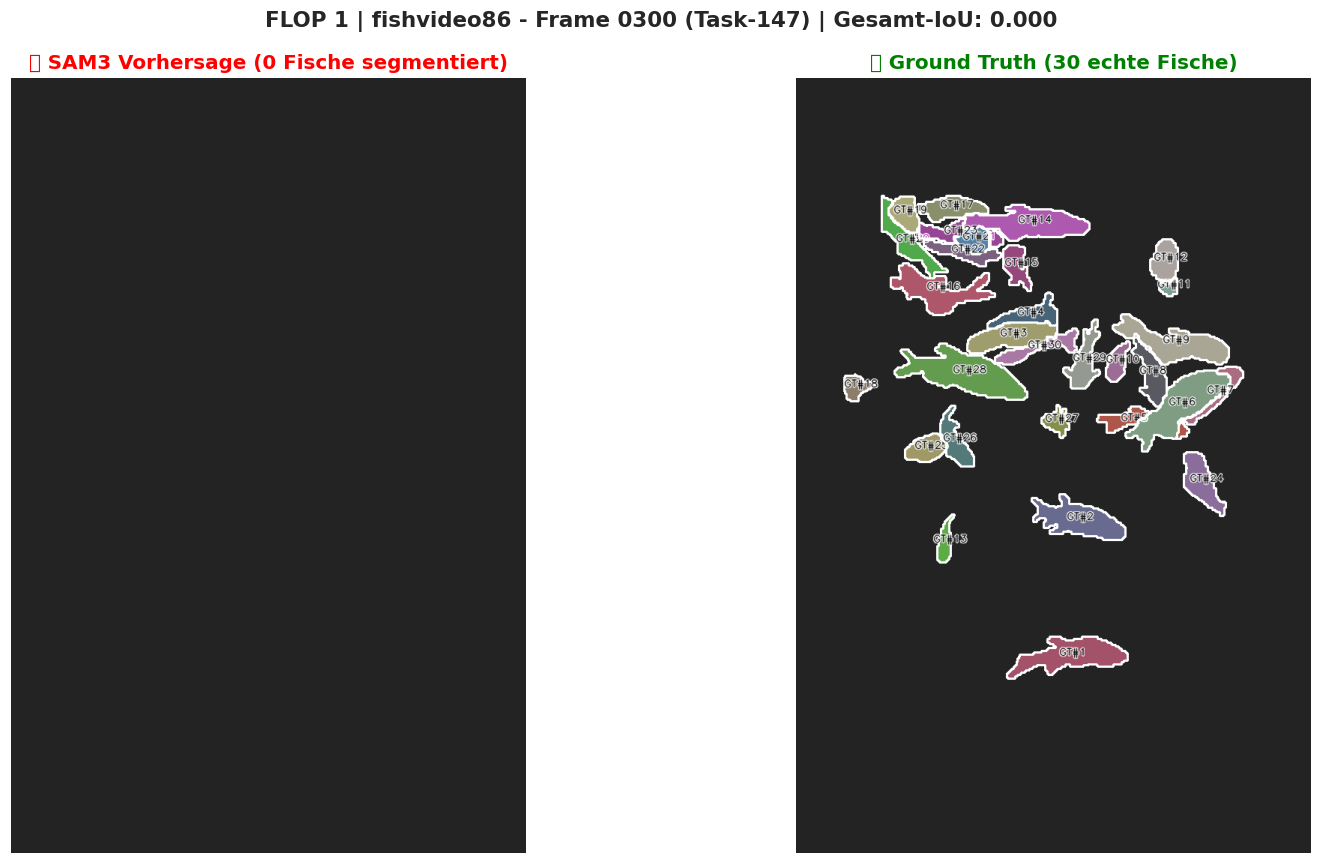

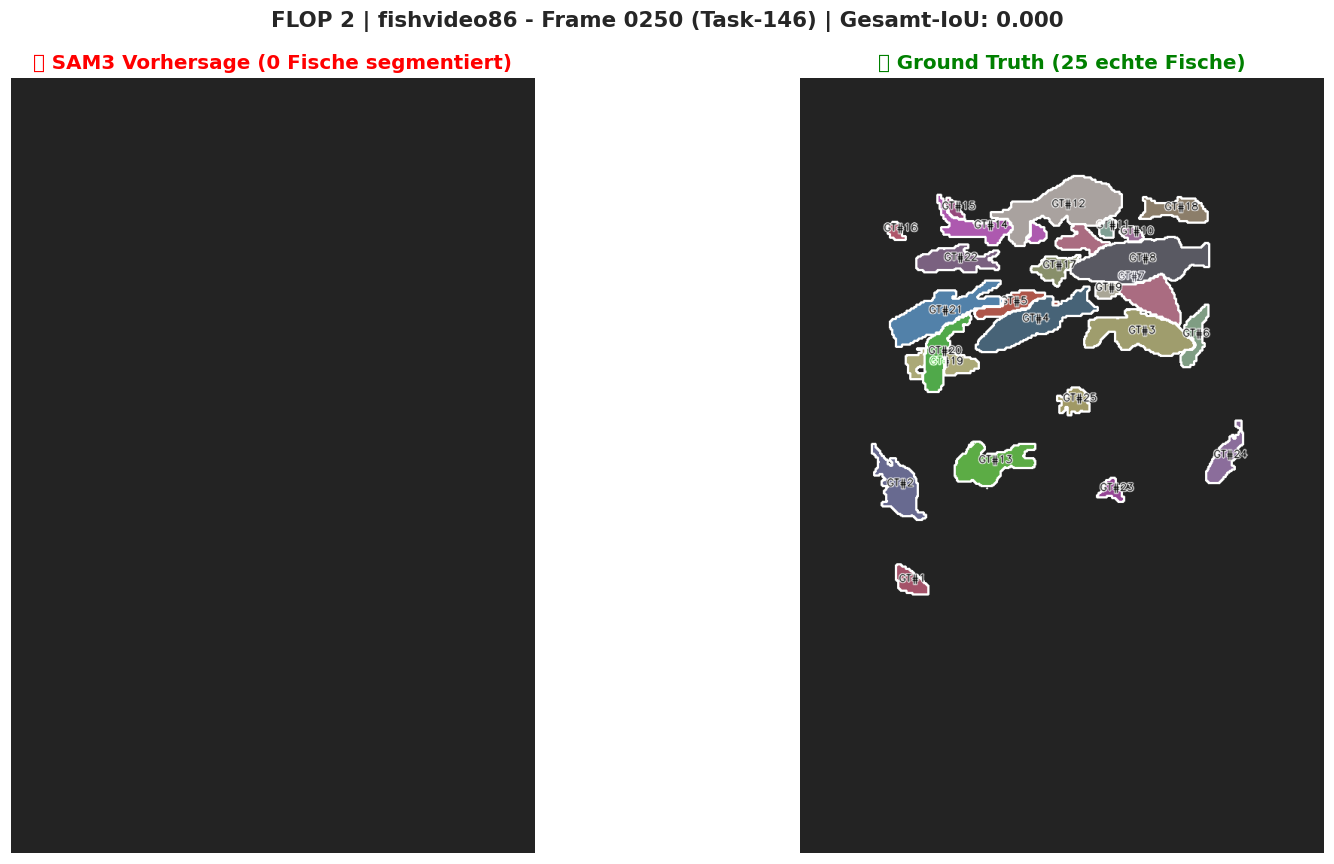

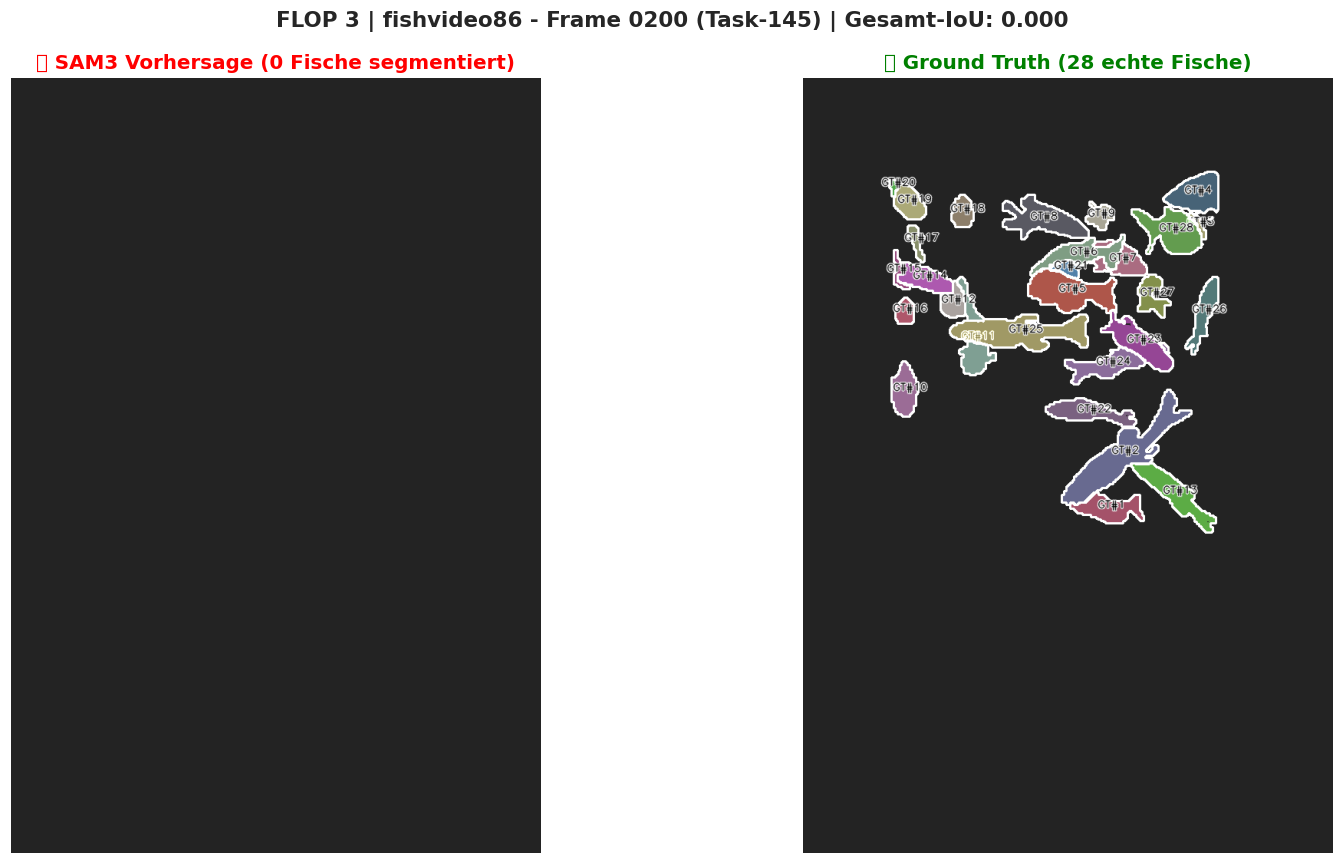

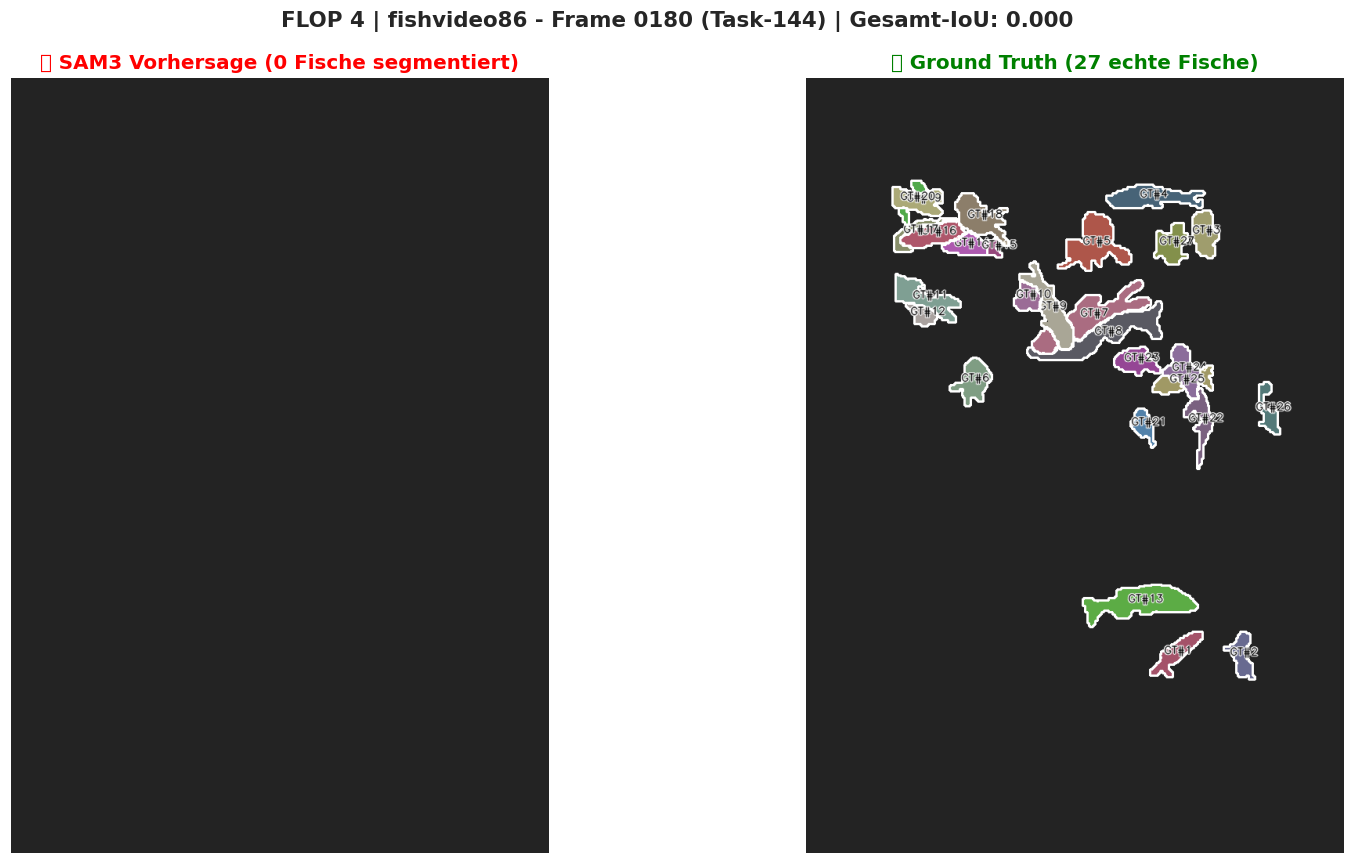

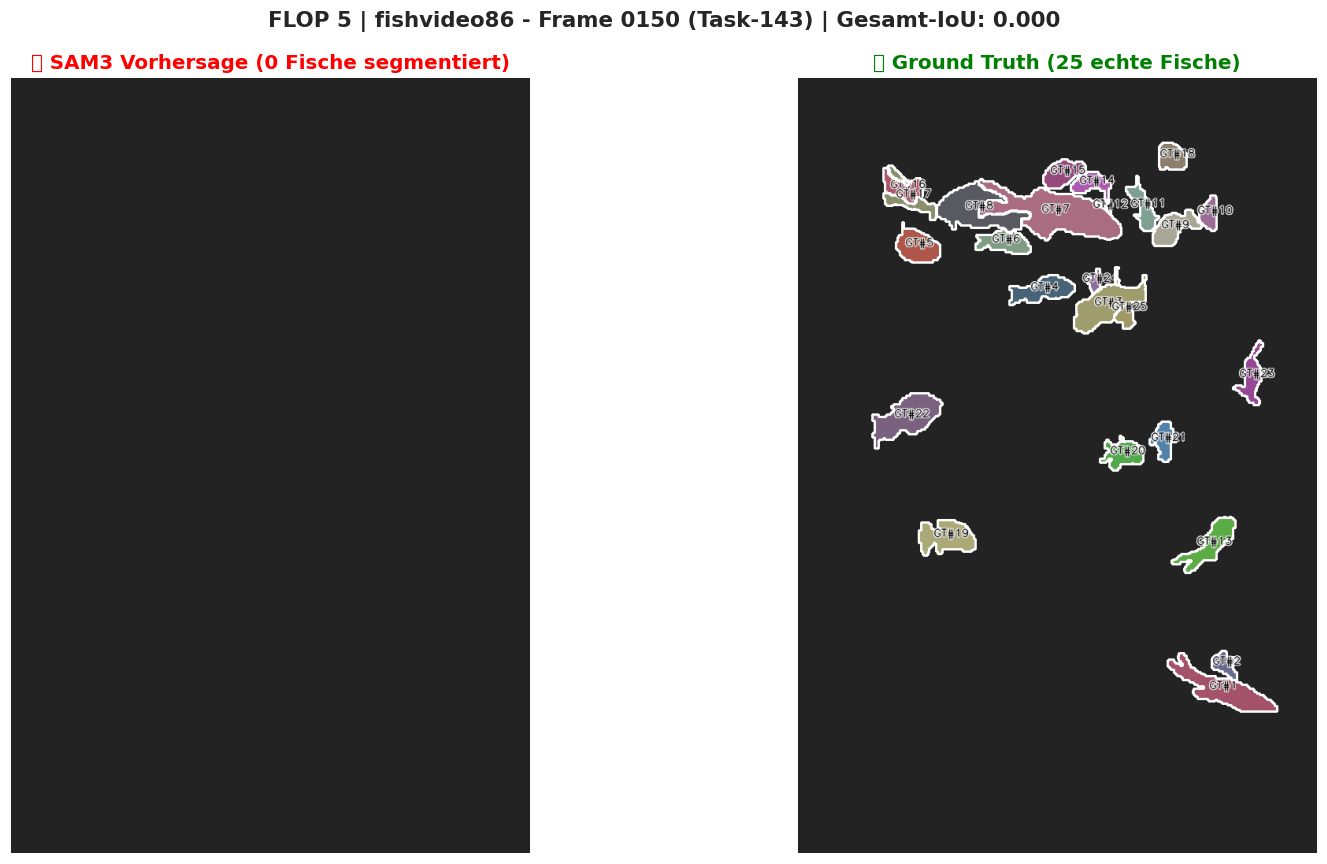

In [4]:
# %% [markdown]
# ### 3. Visuelle Inspektion: TOP 5 & FLOP 5 (Links: SAM3, Rechts: Ground Truth)

# %%
import cv2
import matplotlib.pyplot as plt
import numpy as np


# Hilfsfunktion: Feste, unterscheidbare Farbe pro Instanz
def get_color_for_index(idx):
    np.random.seed(idx * 53 + 7)
    return np.random.randint(60, 255, size=3).tolist()


def plot_sam_sample_comparison(sample, rank_title):
    h_crop, w_crop = sample["h_crop"], sample["w_crop"]

    # 1. Bild laden (oder dunklen Hintergrund erstellen falls Frame-Bild fehlt)
    img_rgb = None
    if "img_path" in sample and sample["img_path"] and sample["img_path"].exists():
        img = cv2.imread(str(sample["img_path"]))
        if img is not None:
            x1, y1, x2, y2 = sample["crop_coords"]
            img_rgb = cv2.cvtColor(img[y1:y2, x1:x2], cv2.COLOR_BGR2RGB)

    if img_rgb is None:
        # Dunkelgrauer Canvas, falls kein Rohbild vorhanden ist
        img_rgb = np.full((h_crop, w_crop, 3), 35, dtype=np.uint8)

    # ---------------------------------------------------------
    # 2. Linkes Overlay: SAM3 Vorhersagen
    # ---------------------------------------------------------
    sam_overlay = img_rgb.copy()
    for idx, inst_mask in enumerate(sample["pred_masks"]):
        color = get_color_for_index(idx)

        layer = np.zeros((h_crop, w_crop, 3), dtype=np.uint8)
        layer[inst_mask == 1] = color
        sam_overlay = cv2.addWeighted(sam_overlay, 1.0, layer, 0.55, 0)

        cnts, _ = cv2.findContours(
            inst_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        cv2.polylines(
            sam_overlay,
            cnts,
            isClosed=True,
            color=(255, 255, 255),
            thickness=2,
        )

        M = cv2.moments(inst_mask)
        if M["m00"] > 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            cv2.putText(
                sam_overlay,
                f"#{idx+1}",
                (max(5, cx - 10), max(15, cy)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                (255, 255, 255),
                2,
                cv2.LINE_AA,
            )
            cv2.putText(
                sam_overlay,
                f"#{idx+1}",
                (max(5, cx - 10), max(15, cy)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                (0, 0, 0),
                1,
                cv2.LINE_AA,
            )

    # ---------------------------------------------------------
    # 3. Rechtes Overlay: Echte Ground Truth Masken
    # ---------------------------------------------------------
    gt_overlay = img_rgb.copy()
    for idx, inst_mask in enumerate(sample["gt_fish_masks"]):
        color = get_color_for_index(idx)

        layer = np.zeros((h_crop, w_crop, 3), dtype=np.uint8)
        layer[inst_mask == 1] = color
        gt_overlay = cv2.addWeighted(gt_overlay, 1.0, layer, 0.55, 0)

        cnts, _ = cv2.findContours(
            inst_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        cv2.polylines(
            gt_overlay, cnts, isClosed=True, color=(255, 255, 255), thickness=2
        )

        M = cv2.moments(inst_mask)
        if M["m00"] > 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            cv2.putText(
                gt_overlay,
                f"GT#{idx+1}",
                (max(5, cx - 15), max(15, cy)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                (255, 255, 255),
                2,
                cv2.LINE_AA,
            )
            cv2.putText(
                gt_overlay,
                f"GT#{idx+1}",
                (max(5, cx - 15), max(15, cy)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                (0, 0, 0),
                1,
                cv2.LINE_AA,
            )

    # ---------------------------------------------------------
    # 4. Nebeneinander Plotten
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=110)

    # Links: SAM3
    axes[0].imshow(sam_overlay)
    axes[0].set_title(
        f"🤖 SAM3 Vorhersage ({sample['num_pred']} Fische segmentiert)",
        fontsize=13,
        fontweight="bold",
        color="blue" if sample["num_pred"] > 0 else "red",
    )
    axes[0].axis("off")

    # Rechts: Ground Truth
    axes[1].imshow(gt_overlay)
    axes[1].set_title(
        f"🎯 Ground Truth ({sample['num_gt']} echte Fische)",
        fontsize=13,
        fontweight="bold",
        color="green",
    )
    axes[1].axis("off")

    plt.suptitle(
        f"{rank_title} | {sample['video']} - Frame {sample['frame']:04d} (Task-{sample['task_id']}) | Gesamt-IoU: {sample['iou']:.3f}",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# SORTIERUNG & AUSGABE
# ---------------------------------------------------------
sorted_samples = sorted(
    evaluated_samples, key=lambda x: x["iou"], reverse=True
)

k = min(5, len(sorted_samples))
top_k = sorted_samples[:k]
# Schlechteste Samples (niedrigste IoU)
flop_k = sorted_samples[-k:][::-1]

print("\n" + "=" * 75)
print(f"       🏆 TOP {k} BESTE ERGEBNISSE (Höchste IoU)")
print("=" * 75)
for rank, sample in enumerate(top_k, 1):
    plot_sam_sample_comparison(sample, f"TOP {rank}")

if len(sorted_samples) > 5:
    print("\n" + "=" * 75)
    print(f"       ⚠️ FLOP {k} SCHLECHTESTE ERGEBNISSE (Niedrigste IoU / Misses)")
    print("=" * 75)
    for rank, sample in enumerate(flop_k, 1):
        plot_sam_sample_comparison(sample, f"FLOP {rank}")